In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
os.chdir("D:\\PhD DS Courses\\14_DDS-7255-Advanced Research Design in DS")

In [3]:
data=pd.read_csv("Fraud_Detection_Dataset.csv")

In [4]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
#  Recreate the Engineered Features
df_fe = data.copy()

# Balance-change features
df_fe["balanceChangeOrig"] = (
    df_fe["oldbalanceOrg"] - df_fe["newbalanceOrig"]
)

df_fe["balanceChangeDest"] = (
    df_fe["newbalanceDest"] - df_fe["oldbalanceDest"]
)

# Transaction amount relative to origin balance
df_fe["transactionRatio"] = (
    df_fe["amount"] / (df_fe["oldbalanceOrg"] + 1)
)

# Temporal features
df_fe["hourOfDay"] = df_fe["step"] % 24
df_fe["day"] = df_fe["step"] // 24

# Large-transaction indicator
df_fe["isLargeTransaction"] = (
    df_fe["amount"] > df_fe["amount"].quantile(0.95)
).astype(int)

df_fe.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceChangeOrig,balanceChangeDest,transactionRatio,hourOfDay,day,isLargeTransaction
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.057834,1,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.087731,1,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0.994505,1,0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,0.994505,1,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0.280788,1,0,0


In [7]:
# Prepare the Modeling Dataset
df_model = df_fe.drop(
    columns=["nameOrig", "nameDest"]
)

df_model = pd.get_dummies(
    df_model,
    columns=["type"],
    drop_first=True
)

print("Modeling dataset shape:", df_model.shape)
df_model.head()

Modeling dataset shape: (6362620, 18)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceChangeOrig,balanceChangeDest,transactionRatio,hourOfDay,day,isLargeTransaction,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0,0.057834,1,0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0,0.087731,1,0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,181.00,0.0,0.994505,1,0,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,181.00,-21182.0,0.994505,1,0,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0,0.280788,1,0,0,False,False,True,False


In [8]:
X = df_model.drop(columns=["isFraud"])
y = df_model["isFraud"]

print("Number of predictors:", X.shape[1])
print("\nTarget distribution:")
print(y.value_counts())

Number of predictors: 17

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [9]:
# Use the Same Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training observations: 5090096
Testing observations: 1272524
Number of features: 17


In [10]:
# Reproduce the Baseline Random Forest
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

# Generate predictions and probabilities:
y_pred_baseline = baseline_rf.predict(X_test)
y_prob_baseline = baseline_rf.predict_proba(X_test)[:, 1]

In [11]:
# Calculate Baseline Metrics
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1-Score": f1_score(y_test, y_pred_baseline),
    "ROC-AUC": roc_auc_score(y_test, y_prob_baseline)
}

baseline_results = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Metric", "Baseline Random Forest"]
)

baseline_results

,Metric,Baseline Random Forest
0,Accuracy,0.999996
1,Precision,0.999390
2,Recall,0.997565
3,F1-Score,0.998477
4,ROC-AUC,0.998781


In [12]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [13]:
# Baseline Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": baseline_rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,transactionRatio,0.330646
7,balanceChangeOrig,0.230905
3,newbalanceOrig,0.105622
5,newbalanceDest,0.079724
8,balanceChangeDest,0.063581
2,oldbalanceOrg,0.050273
0,step,0.030609
1,amount,0.023854
11,day,0.022304
4,oldbalanceDest,0.017333


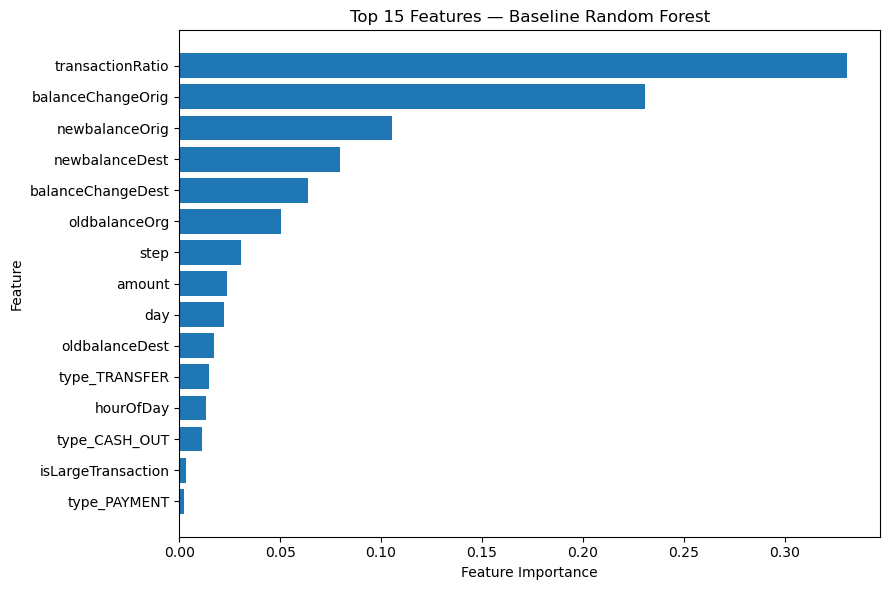

In [14]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Baseline Random Forest")
plt.tight_layout()
plt.show()

### 1.2 Recursive Feature Elimination

Recursive Feature Elimination (RFE) was selected as the alternative feature-selection methodology. RFE repeatedly fits an estimator, ranks predictors according to their contribution, and removes the least important features until the desired number remains.

Because the PaySim training set contains more than five million observations, RFE was performed on a stratified subset of the training data to reduce computational cost. The test set was excluded from the feature-selection process to prevent information leakage.

The objective is to determine whether a reduced feature set can maintain fraud-detection performance while producing a more parsimonious and interpretable model.

In [16]:
# Create the RFE Sample
# Create a stratified sample from the training data
# Separate fraud and non-fraud observations from training data
fraud_idx = y_train[y_train == 1].index
nonfraud_idx = y_train[y_train == 0].sample(
    n=200000,
    random_state=42
).index

# Keep all training fraud cases plus a sample of non-fraud cases
rfe_idx = fraud_idx.union(nonfraud_idx)

X_rfe = X_train.loc[rfe_idx]
y_rfe = y_train.loc[rfe_idx]

print("RFE sample shape:", X_rfe.shape)
print("\nClass distribution:")
print(y_rfe.value_counts())

RFE sample shape: (206570, 17)

Class distribution:
isFraud
0    200000
1      6570
Name: count, dtype: int64


In [17]:
# Configure RFE
rfe_estimator = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=8,
    step=1
)

rfe.fit(X_rfe, y_rfe)

,estimator,RandomForestC...ndom_state=42)
,n_features_to_select,8
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [18]:
# Display the RFE Ranking
rfe_results = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rfe.support_,
    "RFE_Rank": rfe.ranking_
}).sort_values(
    ["Selected", "RFE_Rank"],
    ascending=[False, True]
)

rfe_results

,Feature,Selected,RFE_Rank
1,amount,True,1
2,oldbalanceOrg,True,1
3,newbalanceOrig,True,1
7,balanceChangeOrig,True,1
8,balanceChangeDest,True,1
9,transactionRatio,True,1
15,type_PAYMENT,True,1
16,type_TRANSFER,True,1
10,hourOfDay,False,2
12,isLargeTransaction,False,3


In [19]:
selected_features_rfe = X_train.columns[rfe.support_].tolist()

print("Number of selected features:", len(selected_features_rfe))
print("\nRFE Selected Features:")

for feature in selected_features_rfe:
    print("-", feature)

Number of selected features: 8

RFE Selected Features:
- amount
- oldbalanceOrg
- newbalanceOrig
- balanceChangeOrig
- balanceChangeDest
- transactionRatio
- type_PAYMENT
- type_TRANSFER


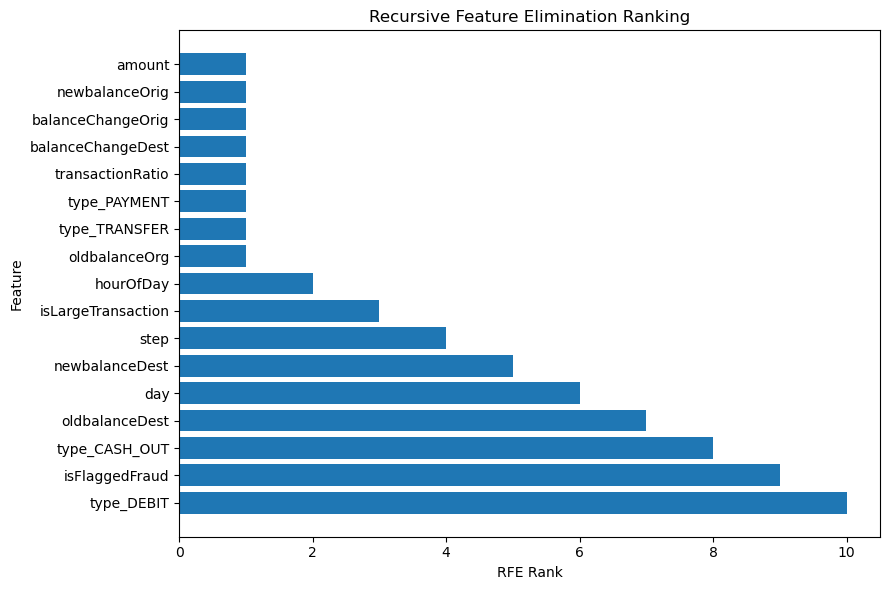

In [20]:
# Visualize the RFE Ranking
rfe_plot = rfe_results.sort_values(
    "RFE_Rank",
    ascending=False
)

plt.figure(figsize=(9, 6))

plt.barh(
    rfe_plot["Feature"],
    rfe_plot["RFE_Rank"]
)

plt.xlabel("RFE Rank")
plt.ylabel("Feature")
plt.title("Recursive Feature Elimination Ranking")

plt.tight_layout()
plt.show()

#### RFE Feature Selection Results

RFE reduced the original 17 predictors to eight features: `amount`, `oldbalanceOrg`, `newbalanceOrig`, `balanceChangeOrig`, `balanceChangeDest`, `transactionRatio`, `type_PAYMENT`, and `type_TRANSFER`. This represents a 52.9% reduction in the number of predictors.

Three engineered variables—`balanceChangeOrig`, `balanceChangeDest`, and `transactionRatio`—were retained, indicating that the engineered balance and transaction-ratio features contain substantial information for distinguishing fraudulent from legitimate transactions. RFE also retained the PAYMENT and TRANSFER transaction indicators while eliminating variables such as `isFlaggedFraud`, `type_DEBIT`, `type_CASH_OUT`, and the engineered temporal variables.

The reduced feature set provides a more parsimonious representation of the data. The next stage evaluates whether this reduction can maintain predictive performance relative to the baseline model using all 17 predictors.

# Part 2 — Model Training and Comparison

In [21]:
# Prepare the RFE Dataset
X_train_rfe = X_train[selected_features_rfe]
X_test_rfe = X_test[selected_features_rfe]

print("Baseline features:", X_train.shape[1])
print("RFE features:", X_train_rfe.shape[1])

print("\nRFE features:")
for feature in selected_features_rfe:
    print("-", feature)

Baseline features: 17
RFE features: 8

RFE features:
- amount
- oldbalanceOrg
- newbalanceOrig
- balanceChangeOrig
- balanceChangeDest
- transactionRatio
- type_PAYMENT
- type_TRANSFER


In [22]:
# Train the RFE Random Forest
rfe_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe_rf.fit(X_train_rfe, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred_rfe = rfe_rf.predict(X_test_rfe)
y_prob_rfe = rfe_rf.predict_proba(X_test_rfe)[:, 1]

In [24]:
# Calculate RFE Model Metrics
rfe_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rfe),
    "Precision": precision_score(y_test, y_pred_rfe),
    "Recall": recall_score(y_test, y_pred_rfe),
    "F1-Score": f1_score(y_test, y_pred_rfe),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rfe)
}

rfe_results_metrics = pd.DataFrame(
    rfe_metrics.items(),
    columns=["Metric", "RFE Random Forest"]
)

rfe_results_metrics

,Metric,RFE Random Forest
0,Accuracy,0.999995
1,Precision,0.998781
2,Recall,0.997565
3,F1-Score,0.998173
4,ROC-AUC,0.998782


In [25]:
print(classification_report(y_test, y_pred_rfe))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [26]:
# Create the Required Comparison Summary Table
comparison_table = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline RF": list(baseline_metrics.values()),
    "RFE RF": list(rfe_metrics.values())
})

comparison_table["Difference"] = (
    comparison_table["RFE RF"] -
    comparison_table["Baseline RF"]
)

comparison_table.round(6)

,Metric,Baseline RF,RFE RF,Difference
0,Accuracy,0.999996,0.999995,-0.000001
1,Precision,0.999390,0.998781,-0.000609
2,Recall,0.997565,0.997565,0.000000
3,F1-Score,0.998477,0.998173,-0.000304
4,ROC-AUC,0.998781,0.998782,0.000001


In [27]:
feature_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "RFE Random Forest"
    ],
    "Number of Features": [
        X_train.shape[1],
        X_train_rfe.shape[1]
    ]
})

feature_comparison

,Model,Number of Features
0,Baseline Random Forest,17
1,RFE Random Forest,8


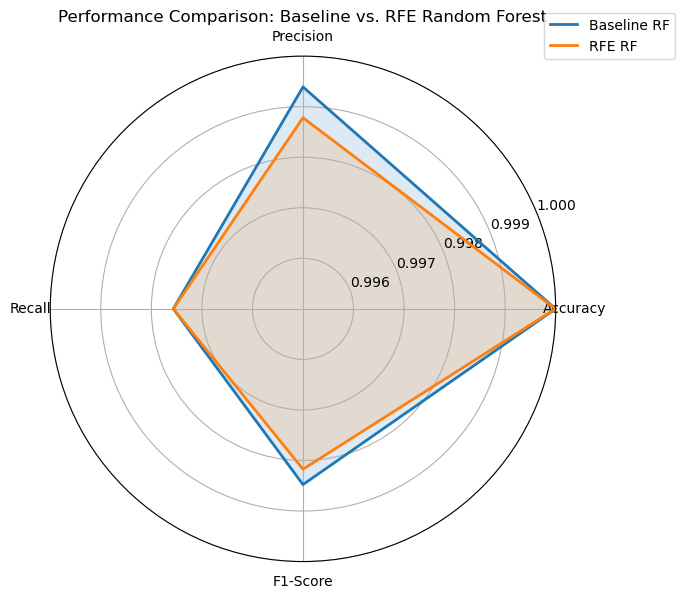

In [28]:
# Spider Chart
metrics_spider = ["Accuracy", "Precision", "Recall", "F1-Score"]

baseline_values = [
    baseline_metrics[m] for m in metrics_spider
]

rfe_values = [
    rfe_metrics[m] for m in metrics_spider
]

# Close the radar chart
baseline_values += baseline_values[:1]
rfe_values += rfe_values[:1]

angles = np.linspace(
    0,
    2 * np.pi,
    len(metrics_spider),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

ax.plot(
    angles,
    baseline_values,
    linewidth=2,
    label="Baseline RF"
)

ax.fill(
    angles,
    baseline_values,
    alpha=0.15
)

ax.plot(
    angles,
    rfe_values,
    linewidth=2,
    label="RFE RF"
)

ax.fill(
    angles,
    rfe_values,
    alpha=0.15
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_spider)

# Zoom in because both models are extremely strong
ax.set_ylim(0.995, 1.000)

plt.title(
    "Performance Comparison: Baseline vs. RFE Random Forest",
    pad=25
)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()
plt.show()

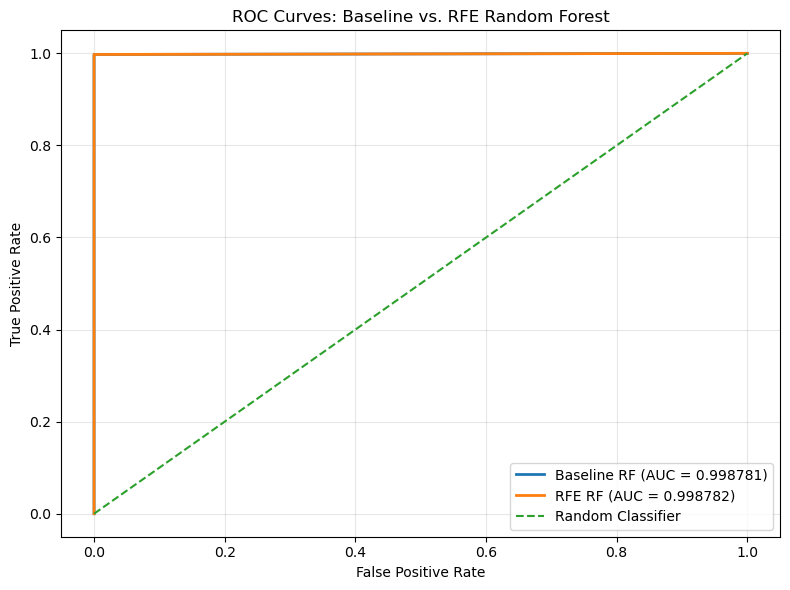

In [29]:
# ROC Curve
fpr_baseline, tpr_baseline, _ = roc_curve(
    y_test,
    y_prob_baseline
)

fpr_rfe, tpr_rfe, _ = roc_curve(
    y_test,
    y_prob_rfe
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    linewidth=2,
    label=f"Baseline RF (AUC = {baseline_metrics['ROC-AUC']:.6f})"
)

plt.plot(
    fpr_rfe,
    tpr_rfe,
    linewidth=2,
    label=f"RFE RF (AUC = {rfe_metrics['ROC-AUC']:.6f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Baseline vs. RFE Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

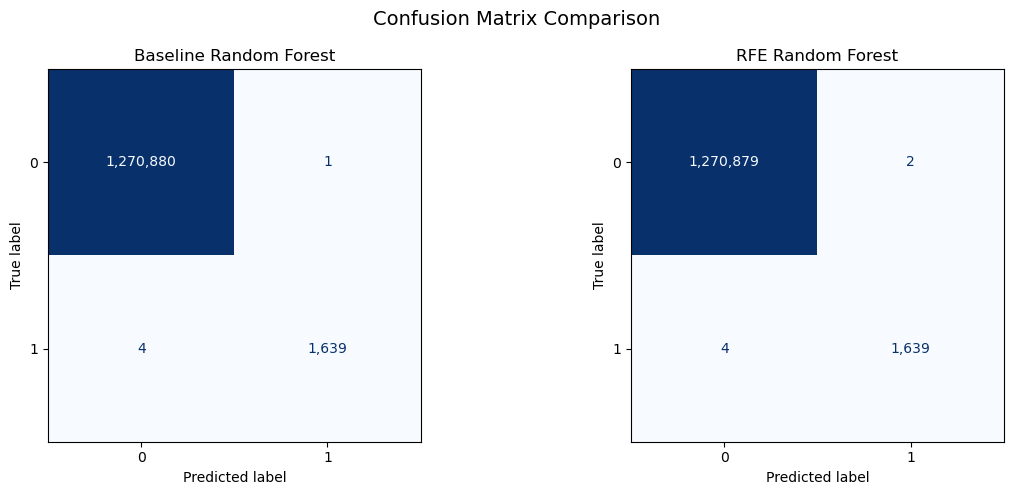

In [30]:
# Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    ax=axes[0],
    values_format=",d",
    cmap="Blues",
    colorbar=False
)

axes[0].set_title(
    "Baseline Random Forest"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rfe,
    ax=axes[1],
    values_format=",d",
    cmap="Blues",
    colorbar=False
)

axes[1].set_title(
    "RFE Random Forest"
)

fig.suptitle(
    "Confusion Matrix Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Model Comparison

RFE reduced the predictor set from 17 to eight features, representing a 52.9% reduction in model dimensionality. Despite this substantial reduction, predictive performance remained nearly unchanged. Recall was identical for both models (0.997565), while ROC-AUC increased marginally from 0.998781 to 0.998782. The RFE model showed only minor decreases in precision (0.999390 to 0.998781) and F1-score (0.998477 to 0.998173).

These results indicate that nine predictors contributed limited additional predictive value to the full Random Forest model. The RFE model therefore achieved a substantially more compact feature representation while preserving nearly all of the baseline model's fraud-detection capability. This finding suggests that feature reduction can improve model parsimony without producing a meaningful loss in predictive performance.